Number of local points = 15


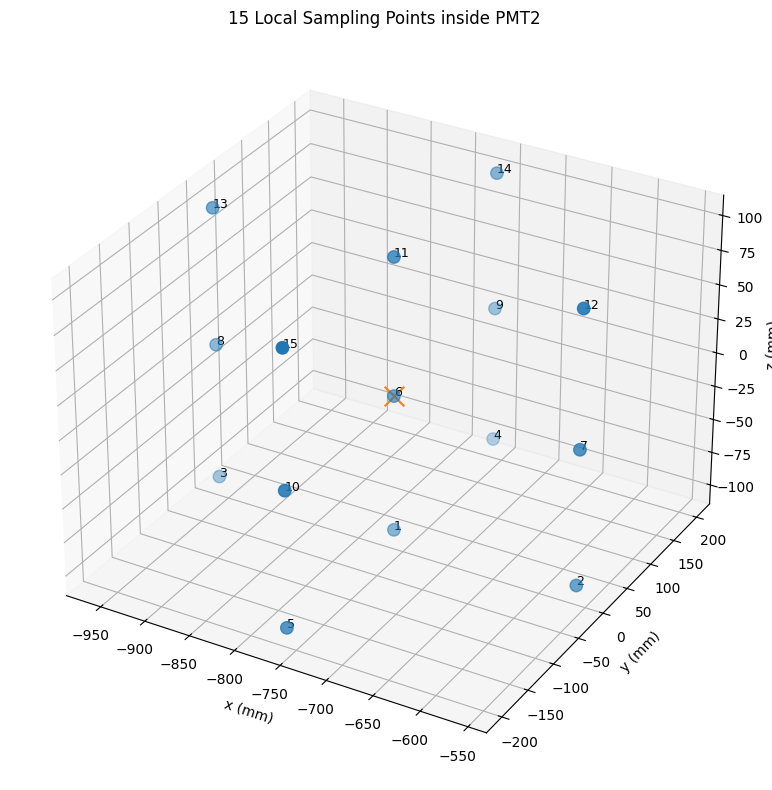

In [1]:
# ============================================================
# LOCAL PMT FIELD UNIFORMITY STUDY
# STEP 1:
# DEFINE 15 LOCAL SAMPLING POINTS
# + PLOT IN 3D
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PMT2 CENTER (m)
# ============================================================

xc = -0.760
yc =  0.000
zc =  0.000

# ============================================================
# LOCAL OFFSETS
# ============================================================
#
# 200 mm = 0.2 m
# 100 mm = 0.1 m
#
# ============================================================

dxy = 0.2
dz  = 0.1

# ============================================================
# BUILD 15 POINTS
# ============================================================

local_points = []

# ------------------------------------------------------------
# Z PLANES
# ------------------------------------------------------------

z_planes = [

    zc - dz,
    zc,
    zc + dz
]

# ------------------------------------------------------------
# PLUS PATTERN
# ------------------------------------------------------------

xy_offsets = [

    (0.0, 0.0),      # center

    (+dxy, 0.0),     # right
    (-dxy, 0.0),     # left

    (0.0, +dxy),     # up
    (0.0, -dxy)      # down
]

# ------------------------------------------------------------
# BUILD POINTS
# ------------------------------------------------------------

for z in z_planes:

    for dx, dy in xy_offsets:

        point = [

            xc + dx,
            yc + dy,
            z
        ]

        local_points.append(point)

# ------------------------------------------------------------
# CONVERT TO ARRAY
# ------------------------------------------------------------

local_points = np.array(local_points)

print("Number of local points =", len(local_points))

# ============================================================
# EXTRACT COORDINATES
# ============================================================

xpts = local_points[:,0]
ypts = local_points[:,1]
zpts = local_points[:,2]

# ============================================================
# 3D PLOT
# ============================================================

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(

    111,
    projection='3d'
)

# ------------------------------------------------------------
# SCATTER POINTS
# ------------------------------------------------------------

ax.scatter(

    xpts * 1000,
    ypts * 1000,
    zpts * 1000,

    s=80
)

# ------------------------------------------------------------
# LABEL POINTS
# ------------------------------------------------------------

for i, (x, y, z) in enumerate(local_points):

    ax.text(

        x*1000,
        y*1000,
        z*1000,

        f'{i+1}',

        fontsize=9
    )

# ------------------------------------------------------------
# PMT CENTER
# ------------------------------------------------------------

ax.scatter(

    xc*1000,
    yc*1000,
    zc*1000,

    s=200,

    marker='x'
)

# ------------------------------------------------------------
# LABELS
# ------------------------------------------------------------

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')

ax.set_title(

    '15 Local Sampling Points inside PMT2'
)

plt.tight_layout()

plt.show()

In [3]:
# ============================================================
# STEP 2:
# BUILD LOCAL TRANSFER MATRIX
#
# A_local :
#
# shape = (45, 7)
#
# 15 points × 3 components
# 7 coils
#
# ============================================================

import sys
import numpy as np

from pathlib import Path

# ============================================================
# ADD PATHS
# ============================================================

project_root = Path.cwd().parent

src_path = project_root / "src"

sys.path.append(str(project_root))
sys.path.append(str(src_path))

# ============================================================
# IMPORT MODULES
# ============================================================

from src.coils import coils
from src.field_solver import total_field_at_point

# ============================================================
# COIL NAMES
# ============================================================

coil_names = [

    'X1',
    'X2',
    'X3',

    'Y1',
    'Y2',

    'Z1',
    'Z2'
]

# ============================================================
# MATRIX SIZES
# ============================================================

n_points = len(local_points)

n_coils = len(coil_names)

# ============================================================
# INITIALIZE MATRICES
# ============================================================

Ax_local = np.zeros((n_points, n_coils))

Ay_local = np.zeros((n_points, n_coils))

Az_local = np.zeros((n_points, n_coils))

# ============================================================
# TESLA -> mG
# ============================================================

mG_conversion = 1e7

# ============================================================
# BUILD MATRICES
# ============================================================

for j, coil_name in enumerate(coil_names):

    print(f'\nComputing field for {coil_name} ...')

    # --------------------------------------------------------
    # UNIT CURRENT CONFIGURATION
    # --------------------------------------------------------

    currents = {

        name: 0.0
        for name in coil_names
    }

    currents[coil_name] = 1.0

    # --------------------------------------------------------
    # LOOP OVER ALL LOCAL POINTS
    # --------------------------------------------------------

    for i, point in enumerate(local_points):

        B = total_field_at_point(

            point,
            coils,
            currents
        )

        # ----------------------------------------------------
        # Tesla -> mG
        # ----------------------------------------------------

        B *= mG_conversion

        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        Ax_local[i, j] = B[0]

        Ay_local[i, j] = B[1]

        Az_local[i, j] = B[2]

# ============================================================
# BUILD FULL MATRIX
# ============================================================

A_local = np.vstack([

    Ax_local,
    Ay_local,
    Az_local
])

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n================================================")

print("LOCAL TRANSFER MATRICES BUILT")

print("================================================")

print("Ax_local shape =", Ax_local.shape)

print("Ay_local shape =", Ay_local.shape)

print("Az_local shape =", Az_local.shape)

print("A_local shape  =", A_local.shape)


Computing field for X1 ...

Computing field for X2 ...

Computing field for X3 ...

Computing field for Y1 ...

Computing field for Y2 ...

Computing field for Z1 ...

Computing field for Z2 ...

LOCAL TRANSFER MATRICES BUILT
Ax_local shape = (15, 7)
Ay_local shape = (15, 7)
Az_local shape = (15, 7)
A_local shape  = (45, 7)


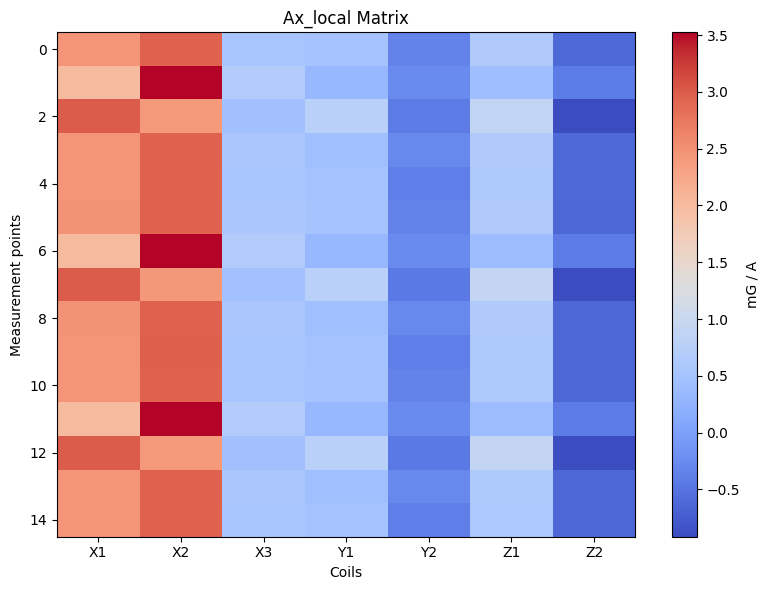

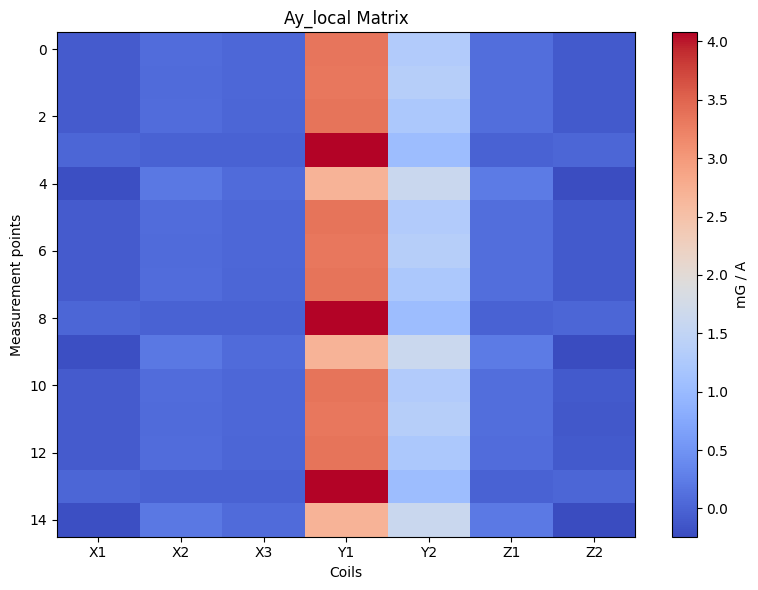

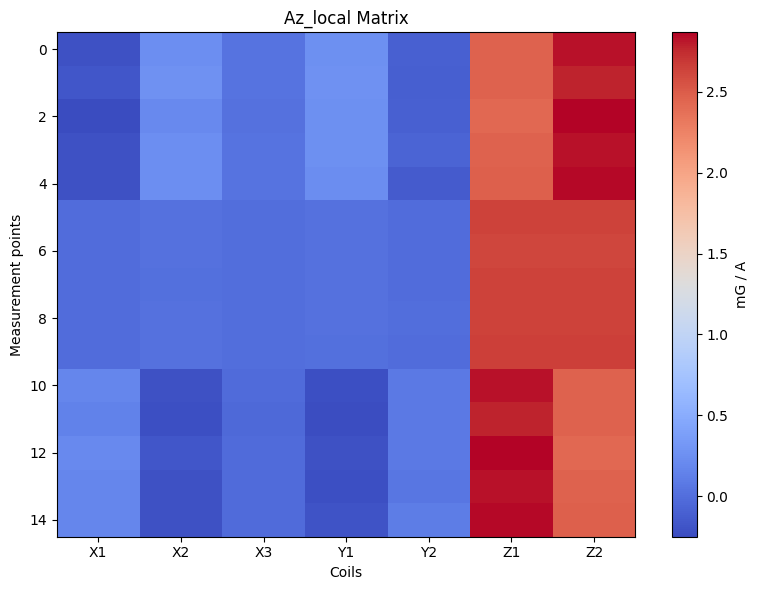

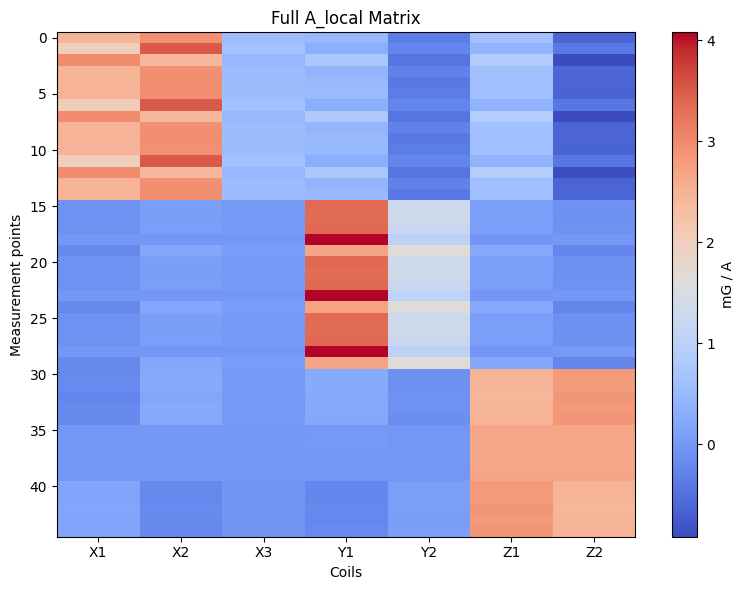

In [4]:
# ============================================================
# STEP 3:
# HEAT MAPS OF LOCAL MATRICES
#
# Ax_local
# Ay_local
# Az_local
# A_local
#
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# COIL LABELS
# ============================================================

coil_labels = [

    'X1',
    'X2',
    'X3',

    'Y1',
    'Y2',

    'Z1',
    'Z2'
]

# ============================================================
# PLOT HEATMAP FUNCTION
# ============================================================

def plot_matrix_heatmap(

    matrix,
    title,
    cmap='coolwarm'
):

    plt.figure(figsize=(8,6))

    im = plt.imshow(

        matrix,

        aspect='auto',

        cmap=cmap
    )

    plt.colorbar(
        im,
        label='mG / A'
    )

    plt.xticks(

        np.arange(len(coil_labels)),
        coil_labels
    )

    plt.xlabel('Coils')

    plt.ylabel('Measurement points')

    plt.title(title)

    plt.tight_layout()

    plt.show()

# ============================================================
# PLOT MATRICES
# ============================================================

plot_matrix_heatmap(

    Ax_local,
    'Ax_local Matrix'
)

plot_matrix_heatmap(

    Ay_local,
    'Ay_local Matrix'
)

plot_matrix_heatmap(

    Az_local,
    'Az_local Matrix'
)

plot_matrix_heatmap(

    A_local,
    'Full A_local Matrix'
)

In [5]:
# ============================================================
# STEP 4:
# OPTIMIZE CURRENTS
# FOR LOCAL FIELD CANCELLATION
#
# Goal:
#
# Bx = 0
# By = 0
# Bz = 0
#
# at all 15 points
#
# ============================================================

# ============================================================
# AMBIENT FIELD (mG)
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

# ============================================================
# BUILD TARGET VECTOR
# ============================================================

target_single = -B_ambient

Bx_target = np.full(

    n_points,
    target_single[0]
)

By_target = np.full(

    n_points,
    target_single[1]
)

Bz_target = np.full(

    n_points,
    target_single[2]
)

B_target = np.concatenate([

    Bx_target,
    By_target,
    Bz_target
])

# ============================================================
# LEAST-SQUARES SOLUTION
# ============================================================

I_opt, residuals, rank, s = np.linalg.lstsq(

    A_local,
    B_target,
    rcond=None
)

# ============================================================
# PRINT CURRENTS
# ============================================================

coil_names = [

    'X1',
    'X2',
    'X3',

    'Y1',
    'Y2',

    'Z1',
    'Z2'
]

print("\n================================================")
print("OPTIMIZED LOCAL CURRENTS")
print("================================================\n")

for name, I in zip(coil_names, I_opt):

    print(f"{name} = {I:.2f} A")


OPTIMIZED LOCAL CURRENTS

X1 = 106.72 A
X2 = 44.52 A
X3 = -50.61 A
Y1 = -29.00 A
Y2 = 6.73 A
Z1 = 20.03 A
Z2 = 124.92 A


In [6]:
# ============================================================
# STEP 5:
# COMPUTE RESIDUAL FIELD
#
# Residual field after optimization
#
# ============================================================

# ============================================================
# COIL FIELD GENERATED
# ============================================================

B_coil = A_local @ I_opt

# ============================================================
# BUILD AMBIENT VECTOR
# ============================================================

B_ambient_vec = np.concatenate([

    np.full(n_points, B_ambient[0]),

    np.full(n_points, B_ambient[1]),

    np.full(n_points, B_ambient[2])
])

# ============================================================
# TOTAL FIELD
# ============================================================

B_total = B_coil + B_ambient_vec

# ============================================================
# SPLIT COMPONENTS
# ============================================================

Bx_residual = B_total[0:n_points]

By_residual = B_total[n_points:2*n_points]

Bz_residual = B_total[2*n_points:3*n_points]

# ============================================================
# FIELD MAGNITUDE
# ============================================================

Bmag_residual = np.sqrt(

    Bx_residual**2 +
    By_residual**2 +
    Bz_residual**2
)

# ============================================================
# PRINT RESIDUALS
# ============================================================

print("\n================================================")
print("RESIDUAL FIELD AT ALL 15 POINTS")
print("================================================\n")

for i in range(n_points):

    print(f"Point {i+1:02d}")

    print(f"Bx = {Bx_residual[i]:8.3f} mG")

    print(f"By = {By_residual[i]:8.3f} mG")

    print(f"Bz = {Bz_residual[i]:8.3f} mG")

    print(f"|B| = {Bmag_residual[i]:8.3f} mG")

    print()

# ============================================================
# GLOBAL METRICS
# ============================================================

print("================================================")
print("UNIFORMITY METRICS")
print("================================================\n")

print(f"Mean residual field     = {np.mean(Bmag_residual):.3f} mG")

print(f"RMS residual variation  = {np.std(Bmag_residual):.3f} mG")

print(f"Maximum residual field  = {np.max(Bmag_residual):.3f} mG")

print(f"Minimum residual field  = {np.min(Bmag_residual):.3f} mG")


RESIDUAL FIELD AT ALL 15 POINTS

Point 01
Bx =    0.117 mG
By =    1.163 mG
Bz =   -0.110 mG
|B| =    1.174 mG

Point 02
Bx =    1.021 mG
By =    1.560 mG
Bz =   -1.451 mG
|B| =    2.362 mG

Point 03
Bx =   -2.546 mG
By =    1.520 mG
Bz =   -1.194 mG
|B| =    3.196 mG

Point 04
Bx =    1.971 mG
By =   -1.176 mG
Bz =   -0.719 mG
|B| =    2.405 mG

Point 05
Bx =    1.101 mG
By =    0.633 mG
Bz =    3.794 mG
|B| =    4.001 mG

Point 06
Bx =   -0.337 mG
By =    0.215 mG
Bz =    0.184 mG
|B| =    0.440 mG

Point 07
Bx =   -0.321 mG
By =    0.585 mG
Bz =   -2.402 mG
|B| =    2.492 mG

Point 08
Bx =   -0.593 mG
By =    0.611 mG
Bz =   -0.721 mG
|B| =    1.115 mG

Point 09
Bx =    1.511 mG
By =   -0.728 mG
Bz =   -0.346 mG
|B| =    1.713 mG

Point 10
Bx =    0.704 mG
By =   -1.326 mG
Bz =    2.273 mG
|B| =    2.725 mG

Point 11
Bx =   -1.605 mG
By =   -0.222 mG
Bz =    0.866 mG
|B| =    1.837 mG

Point 12
Bx =   -2.211 mG
By =    0.121 mG
Bz =   -3.682 mG
|B| =    4.296 mG

Point 13
Bx =    1

In [7]:
# ============================================================
# STEP 6:
# BUILD REDUCED MATRIX
#
# Y1 = Y2 = Y
# Z1 = Z2 = Z
#
# ============================================================

# ============================================================
# REDUCED MATRIX
# ============================================================

A_red_local = np.column_stack([

    A_local[:,0],                  # X1

    A_local[:,1],                  # X2

    A_local[:,2],                  # X3

    A_local[:,3] + A_local[:,4],   # Y

    A_local[:,5] + A_local[:,6]    # Z
])

# ============================================================
# CHECK SHAPE
# ============================================================

print("A_red_local shape =", A_red_local.shape)

# ============================================================
# OPTIMIZATION
# ============================================================

I_red, residuals, rank, s = np.linalg.lstsq(

    A_red_local,
    B_target,
    rcond=None
)

# ============================================================
# PRINT OPTIMIZED CURRENTS
# ============================================================

print("\n================================================")
print("GROUPED CURRENT OPTIMIZATION")
print("================================================\n")

print(f"X1 = {I_red[0]:.3f} A")

print(f"X2 = {I_red[1]:.3f} A")

print(f"X3 = {I_red[2]:.3f} A")

print(f"Y  = {I_red[3]:.3f} A")

print(f"Z  = {I_red[4]:.3f} A")

A_red_local shape = (45, 5)

GROUPED CURRENT OPTIMIZATION

X1 = 61.630 A
X2 = 105.474 A
X3 = -316.139 A
Y  = -21.462 A
Z  = 72.188 A


Your 15-point geometry may be:

over-constraining one side

In [8]:
np.linalg.cond(A_red_local)

np.float64(319.4019113480131)


CASE 1 : GLOBAL PMT OPTIMIZATION

Mean residual field = 7.612 mG
RMS variation       = 3.261 mG
Maximum residual    = 13.740 mG
Minimum residual    = 2.197 mG

CASE 2 : LOCAL VOLUME OPTIMIZATION

Mean residual field = 5.209 mG
RMS variation       = 1.869 mG
Maximum residual    = 9.955 mG
Minimum residual    = 1.889 mG


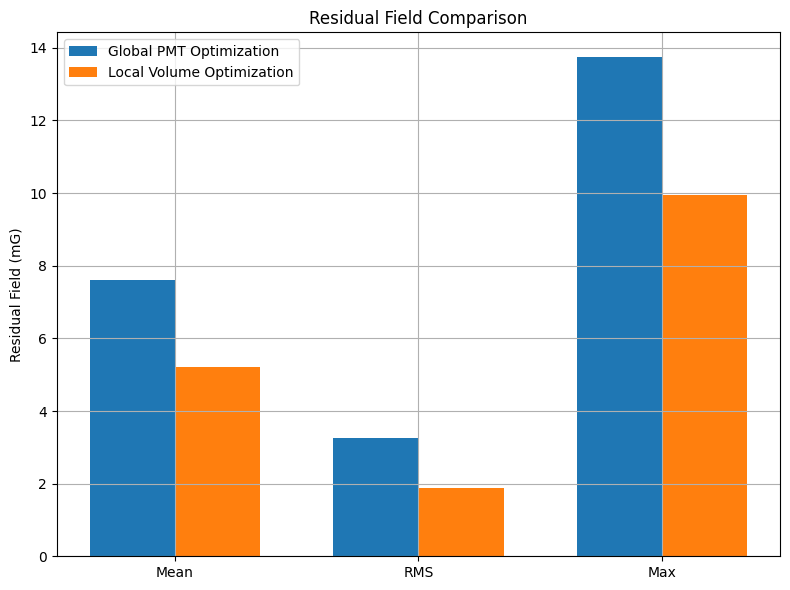

In [9]:
# ============================================================
# STEP 7:
# COMPARE GLOBAL vs LOCAL OPTIMIZATION
#
# CASE 1:
# 6-PMT optimization currents
#
# CASE 2:
# 15-point local optimization currents
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CASE 1:
# GLOBAL PMT OPTIMIZATION
# ============================================================

I_case1 = np.array([

    61,   # X1
    33,   # X2
    68,   # X3

    -23,  # Y
    72    # Z
])

# ============================================================
# CASE 2:
# LOCAL VOLUME OPTIMIZATION
# ============================================================

I_case2 = np.array([

    61,     # X1
    105,    # X2
   -316,    # X3

    -21,    # Y
    72      # Z
])

# ============================================================
# AMBIENT FIELD
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

# ============================================================
# BUILD AMBIENT VECTOR
# ============================================================

B_ambient_vec = np.concatenate([

    np.full(n_points, B_ambient[0]),

    np.full(n_points, B_ambient[1]),

    np.full(n_points, B_ambient[2])
])

# ============================================================
# COMPUTE TOTAL FIELD
# ============================================================

B_case1 = A_red_local @ I_case1 + B_ambient_vec

B_case2 = A_red_local @ I_case2 + B_ambient_vec

# ============================================================
# SPLIT COMPONENTS
# ============================================================

Bx1 = B_case1[0:n_points]
By1 = B_case1[n_points:2*n_points]
Bz1 = B_case1[2*n_points:3*n_points]

Bx2 = B_case2[0:n_points]
By2 = B_case2[n_points:2*n_points]
Bz2 = B_case2[2*n_points:3*n_points]

# ============================================================
# FIELD MAGNITUDES
# ============================================================

Bmag1 = np.sqrt(

    Bx1**2 +
    By1**2 +
    Bz1**2
)

Bmag2 = np.sqrt(

    Bx2**2 +
    By2**2 +
    Bz2**2
)

# ============================================================
# PRINT METRICS
# ============================================================

print("\n================================================")
print("CASE 1 : GLOBAL PMT OPTIMIZATION")
print("================================================\n")

print(f"Mean residual field = {np.mean(Bmag1):.3f} mG")

print(f"RMS variation       = {np.std(Bmag1):.3f} mG")

print(f"Maximum residual    = {np.max(Bmag1):.3f} mG")

print(f"Minimum residual    = {np.min(Bmag1):.3f} mG")

print("\n================================================")
print("CASE 2 : LOCAL VOLUME OPTIMIZATION")
print("================================================\n")

print(f"Mean residual field = {np.mean(Bmag2):.3f} mG")

print(f"RMS variation       = {np.std(Bmag2):.3f} mG")

print(f"Maximum residual    = {np.max(Bmag2):.3f} mG")

print(f"Minimum residual    = {np.min(Bmag2):.3f} mG")

# ============================================================
# BAR PLOT COMPARISON
# ============================================================

labels = [

    'Mean',
    'RMS',
    'Max'
]

case1_metrics = [

    np.mean(Bmag1),
    np.std(Bmag1),
    np.max(Bmag1)
]

case2_metrics = [

    np.mean(Bmag2),
    np.std(Bmag2),
    np.max(Bmag2)
]

x = np.arange(len(labels))

width = 0.35

plt.figure(figsize=(8,6))

plt.bar(

    x - width/2,

    case1_metrics,

    width,

    label='Global PMT Optimization'
)

plt.bar(

    x + width/2,

    case2_metrics,

    width,

    label='Local Volume Optimization'
)

plt.xticks(

    x,
    labels
)

plt.ylabel('Residual Field (mG)')

plt.title('Residual Field Comparison')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


Bx SCAN

------------------------------------------------
Target Bx = 0.0 mG

Optimized currents:
X1 = 61.630 A
X2 = 105.474 A
X3 = -316.139 A
Y  = -21.462 A
Z  = 72.188 A

Field values at 15 points:
[-0.647  1.782 -2.668 -1.388  4.264 -0.732 -0.202  0.353 -1.489  4.246
 -2.486 -1.763  1.331 -3.253  2.527]

Mean = -0.008 mG
RMS  = 2.306 mG

------------------------------------------------
Target Bx = 50.0 mG

Optimized currents:
X1 = 71.381 A
X2 = 113.997 A
X3 = -314.943 A
Y  = -21.444 A
Z  = 72.187 A

Field values at 15 points:
[49.014 52.111 47.617 48.258 53.962 49.118 50.23  50.817 48.346 54.132
 47.228 48.595 51.666 46.445 52.278]

Mean = 49.988 mG
RMS  = 2.330 mG

------------------------------------------------
Target Bx = 100.0 mG

Optimized currents:
X1 = 81.132 A
X2 = 122.521 A
X3 = -313.748 A
Y  = -21.427 A
Z  = 72.186 A

Field values at 15 points:
[ 98.675 102.44   97.902  97.904 103.66   98.967 100.663 101.281  98.18
 104.018  96.941  98.953 102.001  96.144 102.028]

Mean 

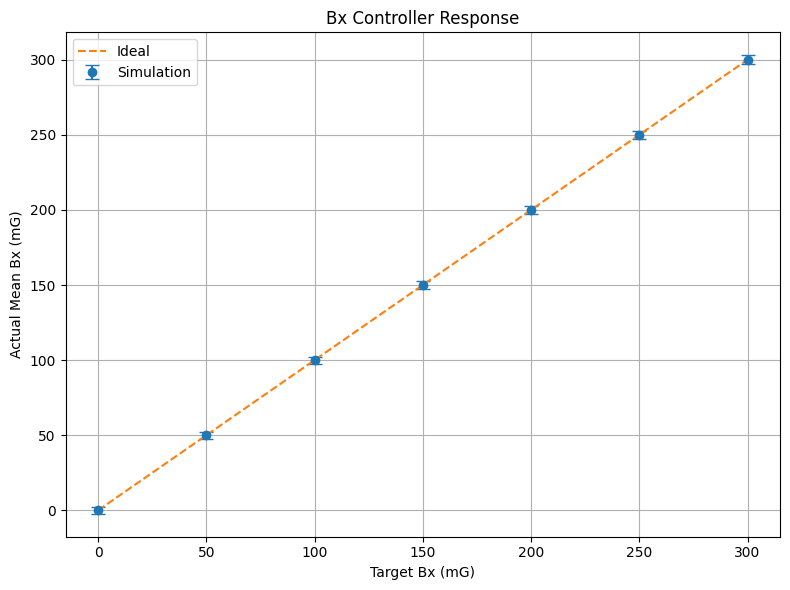

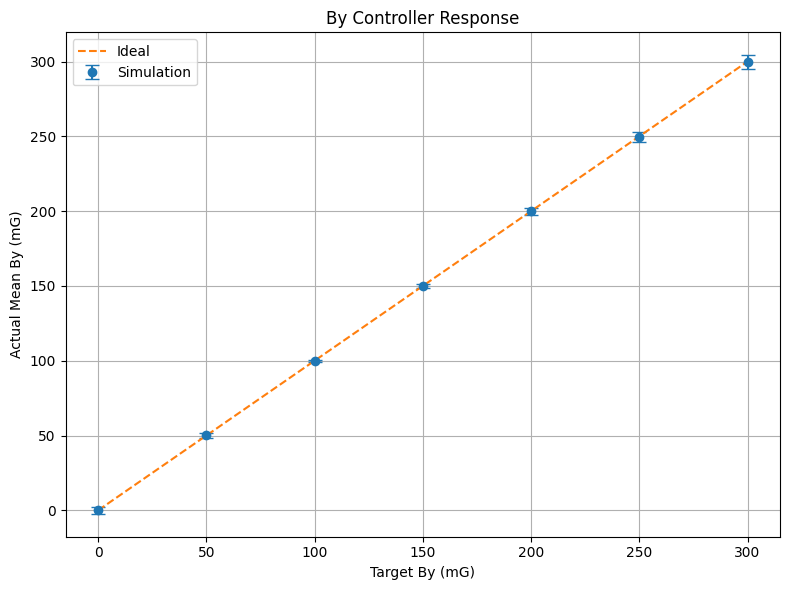

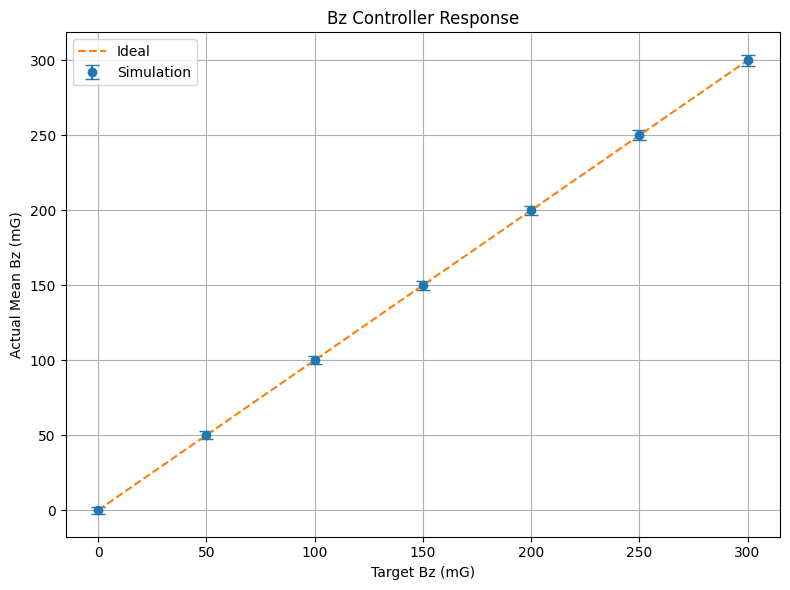

In [10]:
# ============================================================
# STEP 8:
# CONTROLLER RESPONSE SCANS
#
# Bx scan
# By scan
# Bz scan
#
# USING:
# - 15 local PMT points
# - grouped Y coils
# - grouped Z coils
# - independent X coils
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# AMBIENT FIELD
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

# ============================================================
# TARGET FIELD VALUES
# ============================================================

targets = np.arange(

    0,
    301,
    50
)

# ============================================================
# STORAGE
# ============================================================

results = {}

# ============================================================
# COMPONENT LOOP
# ============================================================

components = [

    ('Bx', np.array([1,0,0])),

    ('By', np.array([0,1,0])),

    ('Bz', np.array([0,0,1]))
]

# ============================================================
# MAIN LOOP
# ============================================================

for comp_name, direction in components:

    print("\n================================================")
    print(f"{comp_name} SCAN")
    print("================================================")

    actual_means = []

    actual_rms = []

    current_history = []

    # --------------------------------------------------------
    # TARGET LOOP
    # --------------------------------------------------------

    for target in targets:

        # ----------------------------------------------------
        # USER DESIRED FIELD
        # ----------------------------------------------------

        B_in = target * direction

        # ----------------------------------------------------
        # FIELD COILS MUST GENERATE
        # ----------------------------------------------------

        target_single = B_in - B_ambient

        # ----------------------------------------------------
        # BUILD TARGET VECTOR
        # 15 points × 3 components
        # ----------------------------------------------------

        Bx_vec = np.full(

            n_points,
            target_single[0]
        )

        By_vec = np.full(

            n_points,
            target_single[1]
        )

        Bz_vec = np.full(

            n_points,
            target_single[2]
        )

        B_target = np.concatenate([

            Bx_vec,
            By_vec,
            Bz_vec
        ])

        # ----------------------------------------------------
        # LEAST-SQUARES SOLUTION
        # ----------------------------------------------------

        I_opt, residuals, rank, s = np.linalg.lstsq(

            A_red_local,
            B_target,
            rcond=None
        )

        current_history.append(I_opt)

        # ----------------------------------------------------
        # COIL FIELD
        # ----------------------------------------------------

        B_coil = A_red_local @ I_opt

        # ----------------------------------------------------
        # BUILD AMBIENT VECTOR
        # ----------------------------------------------------

        B_ambient_vec = np.concatenate([

            np.full(n_points, B_ambient[0]),

            np.full(n_points, B_ambient[1]),

            np.full(n_points, B_ambient[2])
        ])

        # ----------------------------------------------------
        # TOTAL FIELD
        # ----------------------------------------------------

        B_actual = B_coil + B_ambient_vec

        # ----------------------------------------------------
        # EXTRACT COMPONENT
        # ----------------------------------------------------

        if comp_name == 'Bx':

            B_component = B_actual[:n_points]

        elif comp_name == 'By':

            B_component = B_actual[n_points:2*n_points]

        else:

            B_component = B_actual[2*n_points:]

        # ----------------------------------------------------
        # STORE METRICS
        # ----------------------------------------------------

        mean_val = np.mean(B_component)

        rms_val = np.std(B_component)

        actual_means.append(mean_val)

        actual_rms.append(rms_val)

        # ----------------------------------------------------
        # PRINT RESULTS
        # ----------------------------------------------------

        print("\n------------------------------------------------")

        print(f"Target {comp_name} = {target:.1f} mG")

        print("\nOptimized currents:")

        print(f"X1 = {I_opt[0]:.3f} A")
        print(f"X2 = {I_opt[1]:.3f} A")
        print(f"X3 = {I_opt[2]:.3f} A")

        print(f"Y  = {I_opt[3]:.3f} A")
        print(f"Z  = {I_opt[4]:.3f} A")

        print("\nField values at 15 points:")

        print(np.round(B_component, 3))

        print(f"\nMean = {mean_val:.3f} mG")

        print(f"RMS  = {rms_val:.3f} mG")

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    results[comp_name] = {

        'targets': targets,

        'means': np.array(actual_means),

        'rms': np.array(actual_rms),

        'currents': current_history
    }

# ============================================================
# PLOTTING
# ============================================================

for comp_name in ['Bx', 'By', 'Bz']:

    plt.figure(figsize=(8,6))

    plt.errorbar(

        results[comp_name]['targets'],

        results[comp_name]['means'],

        yerr=results[comp_name]['rms'],

        fmt='o',

        capsize=5,

        label='Simulation'
    )

    # --------------------------------------------------------
    # IDEAL RESPONSE
    # --------------------------------------------------------

    plt.plot(

        results[comp_name]['targets'],

        results[comp_name]['targets'],

        '--',

        label='Ideal'
    )

    plt.xlabel(f'Target {comp_name} (mG)')

    plt.ylabel(f'Actual Mean {comp_name} (mG)')

    plt.title(f'{comp_name} Controller Response')

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [11]:
# ============================================================
# NOTEBOOK 09
#
# Bx SCAN INSIDE PMT2 VOLUME
#
# TARGET FIELD:
#
# (Bx, By, Bz)
#
# =
#
# (-300,0,0) → (+300,0,0)
#
# OPTIMIZATION OVER:
# 15 LOCAL POINTS
#
# ============================================================

import sys
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# ADD PROJECT ROOT
# ============================================================

project_root = Path.cwd().parent

sys.path.append(str(project_root))

# ============================================================
# IMPORT MODULES
# ============================================================

from src.geometry import build_all_coils
from src.field_solver import total_field_at_point

# ============================================================
# BUILD COILS
# ============================================================

coils = build_all_coils()

coil_names = [

    'X1',
    'X2',
    'X3',

    'Y1',
    'Y2',

    'Z1',
    'Z2'
]

# ============================================================
# PMT2 CENTER
# ============================================================

xc = -760e-3
yc = 0e-3
zc = 0e-3

# ============================================================
# BUILD 15 LOCAL POINTS
#
# z = -100 mm
# z =   0 mm
# z = +100 mm
#
# each plane:
# center + cross pattern
# ============================================================

offset = 200e-3

z_planes = [

    -100e-3,
     0e-3,
     100e-3
]

local_points = []

for dz in z_planes:

    z = zc + dz

    plane_points = [

        [xc, yc, z],

        [xc + offset, yc, z],
        [xc - offset, yc, z],

        [xc, yc + offset, z],
        [xc, yc - offset, z]
    ]

    local_points.extend(plane_points)

local_points = np.array(local_points)

# ============================================================
# PLOT LOCAL POINTS
# ============================================================

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(

    local_points[:,0] * 1000,
    local_points[:,1] * 1000,
    local_points[:,2] * 1000,

    s=80
)

ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_zlabel('z (mm)')

ax.set_title('15 Local PMT2 Points')

plt.tight_layout()
plt.show()

# ============================================================
# BUILD LOCAL MATRICES
# ============================================================

n_points = len(local_points)

n_coils = len(coil_names)

Ax_local = np.zeros((n_points, n_coils))

Ay_local = np.zeros((n_points, n_coils))

Az_local = np.zeros((n_points, n_coils))

# ============================================================
# UNIT CONVERSION
# Tesla -> mG
# ============================================================

mG_conversion = 1e7

# ============================================================
# BUILD MATRICES
# ============================================================

for j, coil_name in enumerate(coil_names):

    print(f'Computing column for {coil_name} ...')

    currents = {

        name: 0.0
        for name in coil_names
    }

    currents[coil_name] = 1.0

    for i, point in enumerate(local_points):

        B = total_field_at_point(

            point,
            coils,
            currents
        )

        B *= mG_conversion

        Ax_local[i,j] = B[0]

        Ay_local[i,j] = B[1]

        Az_local[i,j] = B[2]

# ============================================================
# BUILD FULL MATRIX
# ============================================================

A_local = np.vstack([

    Ax_local,
    Ay_local,
    Az_local
])

print("\nA_local shape =", A_local.shape)

# ============================================================
# GROUP Y AND Z COILS
# ============================================================

A_red_local = np.column_stack([

    A_local[:,0],                 # X1
    A_local[:,1],                 # X2
    A_local[:,2],                 # X3

    A_local[:,3] + A_local[:,4], # Y

    A_local[:,5] + A_local[:,6]  # Z
])

print("A_red_local shape =", A_red_local.shape)

# ============================================================
# AMBIENT FIELD
# ============================================================

B_ambient = np.array([

    -283.38,
     106.79,
    -381.21
])

# ============================================================
# TARGET FIELD SCAN
# ============================================================

Bx_targets = np.arange(

    -300,
     301,
     50
)

# ============================================================
# STORAGE
# ============================================================

Bx_actual_mean = []

Bx_actual_rms = []

all_currents = []

# ============================================================
# MAIN OPTIMIZATION LOOP
# ============================================================

for Bx_target in Bx_targets:

    print("\n================================================")

    print(f"TARGET Bx = {Bx_target} mG")

    # --------------------------------------------------------
    # USER TARGET FIELD
    # --------------------------------------------------------

    B_in = np.array([

        Bx_target,
        0,
        0
    ])

    # --------------------------------------------------------
    # FIELD COILS MUST GENERATE
    # --------------------------------------------------------

    target_single = B_in - B_ambient

    # --------------------------------------------------------
    # BUILD TARGET VECTOR
    # --------------------------------------------------------

    Bx_vec = np.full(

        n_points,
        target_single[0]
    )

    By_vec = np.full(

        n_points,
        target_single[1]
    )

    Bz_vec = np.full(

        n_points,
        target_single[2]
    )

    B_target = np.concatenate([

        Bx_vec,
        By_vec,
        Bz_vec
    ])

    # ========================================================
    # LEAST-SQUARES OPTIMIZATION
    # ========================================================

    I_opt, residuals, rank, s = np.linalg.lstsq(

        A_red_local,
        B_target,
        rcond=None
    )

    all_currents.append(I_opt)

    # ========================================================
    # TOTAL FIELD
    # ========================================================

    B_coil = A_red_local @ I_opt

    B_ambient_vec = np.concatenate([

        np.full(n_points, B_ambient[0]),

        np.full(n_points, B_ambient[1]),

        np.full(n_points, B_ambient[2])
    ])

    B_actual = B_coil + B_ambient_vec

    # ========================================================
    # EXTRACT Bx
    # ========================================================

    Bx_actual = B_actual[:n_points]

    # ========================================================
    # STATISTICS
    # ========================================================

    mean_Bx = np.mean(Bx_actual)

    rms_Bx = np.std(Bx_actual)

    Bx_actual_mean.append(mean_Bx)

    Bx_actual_rms.append(rms_Bx)

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\nOptimized currents:")

    print(f"X1 = {I_opt[0]:.3f} A")
    print(f"X2 = {I_opt[1]:.3f} A")
    print(f"X3 = {I_opt[2]:.3f} A")

    print(f"Y  = {I_opt[3]:.3f} A")
    print(f"Z  = {I_opt[4]:.3f} A")

    print("\nBx field at 15 points:")

    print(np.round(Bx_actual, 3))

    print(f"\nMean Bx = {mean_Bx:.3f} mG")

    print(f"RMS spread = {rms_Bx:.3f} mG")

# ============================================================
# CONVERT TO ARRAYS
# ============================================================

Bx_actual_mean = np.array(Bx_actual_mean)

Bx_actual_rms = np.array(Bx_actual_rms)

# ============================================================
# PLOT:
# TARGET vs ACTUAL
# ============================================================

plt.figure(figsize=(8,6))

plt.errorbar(

    Bx_targets,

    Bx_actual_mean,

    yerr=Bx_actual_rms,

    fmt='o',

    capsize=5,

    label='Simulation'
)

# ------------------------------------------------------------
# IDEAL RESPONSE
# ------------------------------------------------------------

plt.plot(

    Bx_targets,

    Bx_targets,

    '--',

    label='Ideal'
)

plt.xlabel('Target Bx (mG)')

plt.ylabel('Actual Mean Bx (mG)')

plt.title('Bx Controller Response')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================
# PLOT:
# RMS vs TARGET FIELD
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    Bx_targets,

    Bx_actual_rms,

    'o-'
)

plt.xlabel('Target Bx (mG)')

plt.ylabel('RMS Spread (mG)')

plt.title('Field Uniformity vs Target Bx')

plt.grid(True)

plt.tight_layout()

plt.show()

ImportError: cannot import name 'build_all_coils' from 'src.geometry' (C:\Users\Guru Jahnavi Madana\magnetic_compensation\src\geometry.py)